<a href="https://colab.research.google.com/github/mgcavallotti/Repositorio-I/blob/main/practica_vectorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install sympy_plot_backends
!git clone http://github.com/joaquinr-uner/cvyed
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import collections
import spb
from cvyed import esfera, cilindro, paraboloide, cono

fatal: destination path 'cvyed' already exists and is not an empty directory.


In [ ]:
#Funciones
x, y, z = sp.symbols("x y z")


def plano_tangente(f, x0, y0):
  x, y, z = sp.symbols('x y z')

  fx = sp.diff(f, x)
  fy = sp.diff(f, y)

  f0 = f.subs({x: x0, y: y0})
  fx0 = fx.subs({x: x0, y: y0})
  fy0 = fy.subs({x: x0, y: y0})

  plano = sp.Eq(z, f0 + fx0*(x - x0) + fy0*(y - y0))
  return plano


def direccional(f, u):
  x, y, z = sp.symbols('x y z')
  Fx = f.diff(x)
  Fy = f.diff(y)
  gradF = sp.Matrix([Fx,Fy])
  norma = u.norm()
  if norma ==1:
    dir = gradF.dot(u)
  else:
    u2 = u * (1/ (norma))
    dir = gradF.dot(u2)
  return dir


#https://colab.research.google.com/drive/16kUezdH7z2W7r0oeAQ76vgDRBtfVtduW?hl=en-GB#scrollTo=kNTqUsN-NNta









In [11]:
t=sp.symbols('t')
x, y, z = sp.symbols('x y z')
T = sp.Eq(z, 20 + (10 * (1/(sp.exp(0.3 * (x**2 + y**2))))))
r = sp.Matrix([sp.cos(t-2), sp.sin(2*t)])
P= sp.Matrix(r.subs(t, 0.6))

z0 = T.rhs
Tx = z0.diff(x)
Ty = z0.diff(y)
gradT = sp.Matrix([Tx , Ty])
cambioT = gradT.subs({x: P[0] , y: P[1] })

print("El cambio en x es: ", cambioT[0], "El cambio en y es: ", cambioT[1])



El cambio en x es:  -0.779060654085055 El cambio en y es:  -4.27209028495963


La derivada de T en direccion del vector (3,1) desde el punto (1,1) es:  24


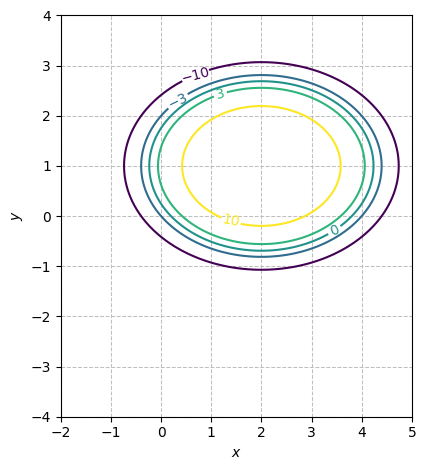

In [9]:
F = 20 - 4*((x-2)**2) - 7*((y-1)**2)
Fx = F.diff(x)
Fy = F.diff(y)
gradF = sp.Matrix([Fx, Fy])
u = gradF.subs({x: 1, y: 1})
v= sp.Matrix([3,1])
norma = v.norm()
v_unit = (1/norma)* v
direccional = u.dot(v)
print("La derivada de T en direccion del vector (3,1) desde el punto (1,1) es: ", direccional)


spb.plot_contour(F , (x, -2 , 5), (y, -4 , 4 ), {"levels": [-10, -3, 0, 3, 10]}, is_filled=False, aspect=(1,1), show=True)


/usr/local/lib/python3.12/dist-packages/spb/series/series_2d_3d.py:1307: UserWarning: The following keyword arguments are unused by `ContourSeries`.
* 'levels': did you mean 'label'?



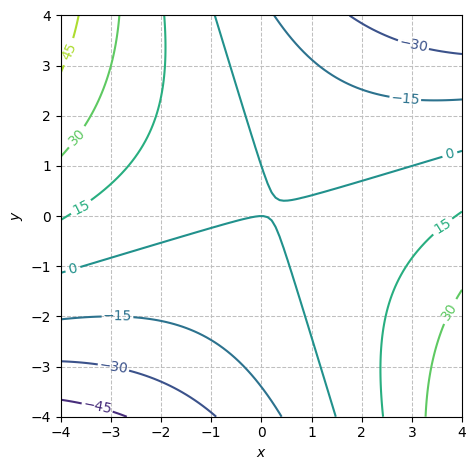

Plot object containing:
[0]: contour: x**2 - 3*x*y - y**2 + y for x over (-4, 4) and y over (-4, 4)


In [19]:
G = x**2 -3*x*y +y -y**2

Gx = G.diff(x)
Gy = G.diff(y)

gradG = [Gx, Gy]

d1 = tuple(gradG.subs({x: 1, y: 1}))
d2 = tuple(gradG.subs({x: -1, y: 1}))
d3 = tuple(gradG.subs({x: -1, y: -1}))
d4 = tuple(gradG.subs({x: 1, y: -1}))

p1 = G.subs({x:1 , y: 1})
p2 = G.subs({x:-1 , y: 1})
p3 = G.subs({x: -1 , y: -1})
p4 = G.subs({x: 1, y: -1 })

h = spb.plot_contour(G, (x, -4, 4), (y, -4, 4), levels= [p1, p2, p3, p4], is_filled=False, show=True, aspect = (1,1))

vec = spb.plot_vector()

#suma de graficas vec y h
print(h)
